## 🎯 Étape Finale : Pipeline Complet avec Modèle Fine-Tuné

# YOLO Fine-Tuné (vos images) → EfficientNet (classification)

##   Cellule 1 - Pipeline Final Optimisé

In [1]:
# Pipeline Final : YOLO Fine-Tuné + EfficientNet
from ultralytics import YOLO
import torch
from pathlib import Path
import cv2
import json
import matplotlib.pyplot as plt
import numpy as np
import sys

sys.path.insert(0, '.')
from src.model import VehicleClassifier
from src.dataset import get_transforms

# Charger YOLO Fine-Tuné (VOS images parking)
yolo_finetuned = YOLO('runs/detect/models/yolo_parking_finetuned/parking_detector/weights/best.pt')
print('✅ YOLO Fine-Tuné chargé (146 images parking)')

# Charger EfficientNet
EFFICIENTNET_DIR = Path('models/efficientnet_classifier_v2_production_50epochs')
EFFICIENTNET_MODEL = EFFICIENTNET_DIR / 'best_model_final.pth'
CLASS_NAMES_FILE = EFFICIENTNET_DIR / 'class_names.json'

with open(CLASS_NAMES_FILE) as f:
    vehicle_classes = json.load(f)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
classifier = VehicleClassifier(num_classes=len(vehicle_classes), pretrained=False)
checkpoint = torch.load(EFFICIENTNET_MODEL, map_location=device)
classifier.load_state_dict(checkpoint['model_state_dict'])
classifier = classifier.to(device)
classifier.eval()

print(f'✅ EfficientNet chargé - Acc: {checkpoint["val_acc"]:.2f}%')
print(f'✅ Device: {device}')
print('\n🎯 Pipeline complet opérationnel!')

✅ YOLO Fine-Tuné chargé (146 images parking)
✅ EfficientNet chargé - Acc: 81.75%
✅ Device: cuda

🎯 Pipeline complet opérationnel!


##  Cellule 2 - Fonction Pipeline Final

In [2]:
def predict_pipeline_final(image_path, yolo_model, classifier, vehicle_classes, device):
    """
    Pipeline FINAL optimisé:
    YOLO Fine-Tuné → Crop précis → EfficientNet Classification
    """
    # Charger image
    image = cv2.imread(str(image_path))
    if image is None:
        return None, None, "Image introuvable"
    
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w = image.shape[:2]
    
    # Détection YOLO Fine-Tuné
    yolo_results = yolo_model(image, conf=0.25, verbose=False)
    
    if len(yolo_results[0].boxes) == 0:
        return None, image_rgb, "Aucun véhicule détecté"
    
    # Prendre meilleure détection
    box = yolo_results[0].boxes[0]
    x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
    yolo_conf = float(box.conf[0])
    
    # Crop véhicule (bbox déjà précise grâce au fine-tuning!)
    vehicle_crop = image_rgb[y1:y2, x1:x2]
    
    # Classification EfficientNet
    transform = get_transforms(img_size=224, is_train=False)
    transformed = transform(image=vehicle_crop)['image'].unsqueeze(0).to(device)
    
    with torch.no_grad():
        outputs = classifier(transformed)
        probs = torch.softmax(outputs, dim=1)
        top_k_probs, top_k_idx = torch.topk(probs, 3)
    
    top_3_classes = [vehicle_classes[idx.item()] for idx in top_k_idx[0]]
    top_3_probs = top_k_probs[0].cpu().numpy()
    
    return {
        'bbox': [x1, y1, x2, y2],
        'yolo_conf': yolo_conf,
        'top_3_classes': top_3_classes,
        'top_3_probs': top_3_probs,
        'vehicle_crop': vehicle_crop
    }, image_rgb, None

print('✅ Pipeline final prêt!')

✅ Pipeline final prêt!


##  Cellule 3 - Test Pipeline Final

/tmp/ipykernel_347668/1929811144.py:36: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/alpr_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


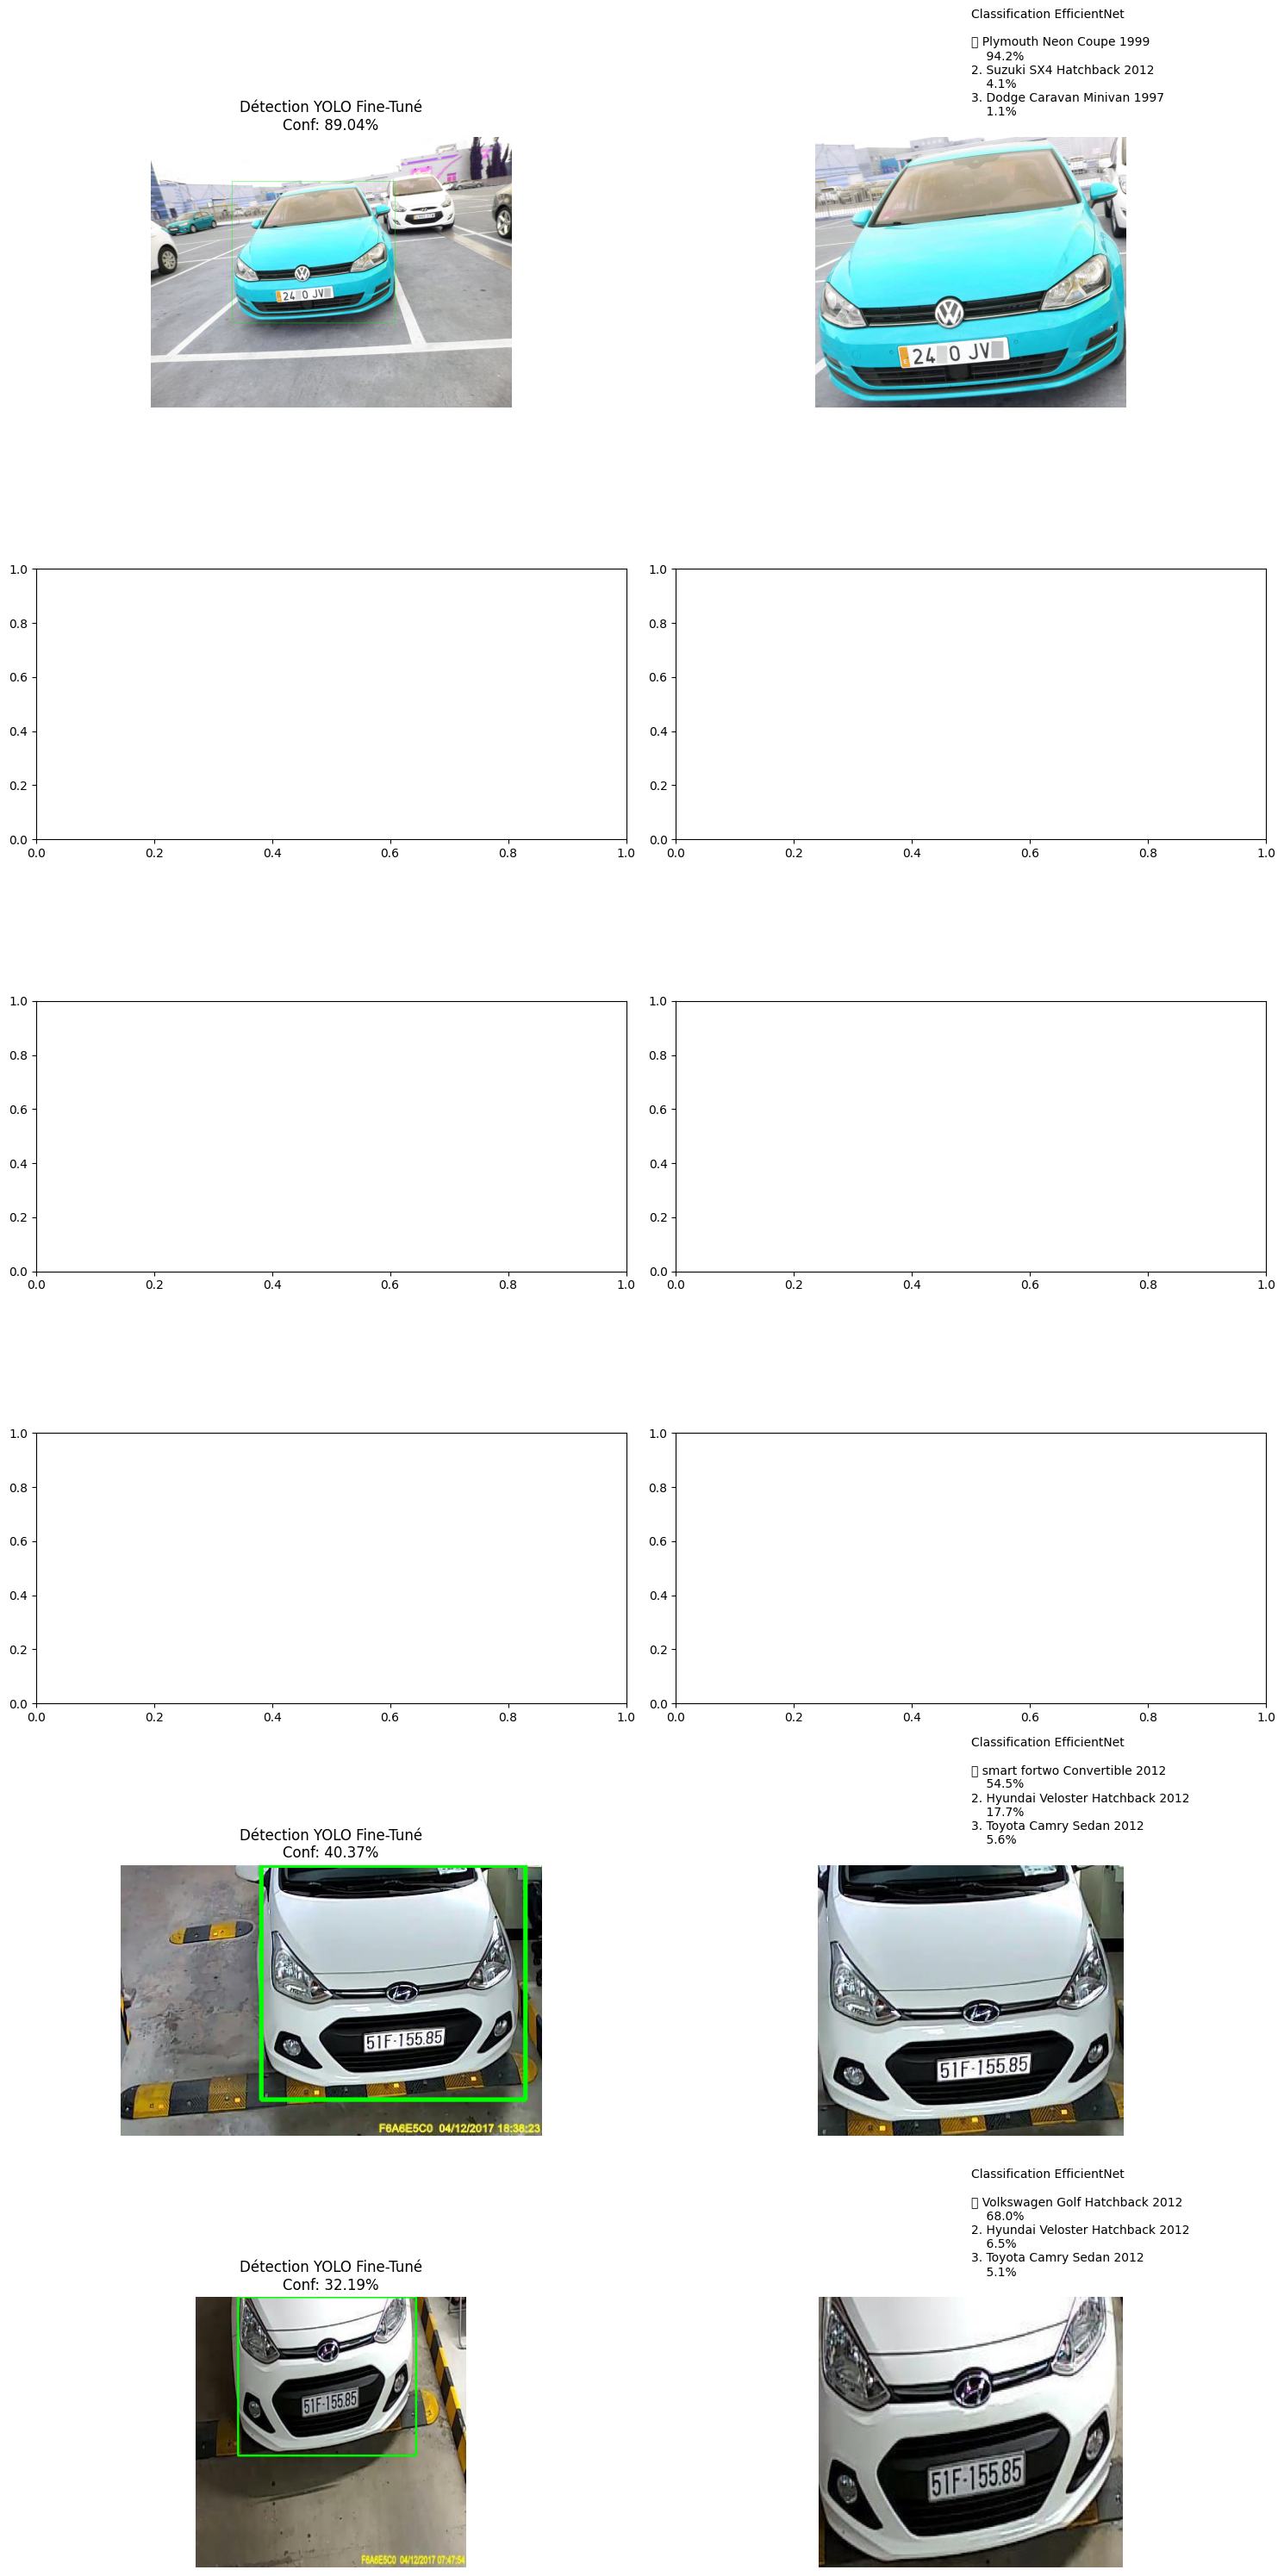


✅ Pipeline Final testé!
🎯 YOLO Fine-Tuné (vos images) + EfficientNet (Stanford Cars)


In [3]:
# Tester sur vos images
test_images = [
    '/mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/MODEL_YOLO8-n_&_OCR/ROBOFLOW_universe/sample/00026.jpg',  # VW Golf
    '/mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/MODEL_YOLO8-n_&_OCR/ROBOFLOW_universe/sample/00064.jpg',  # Mitsubishi immeuble
    '/mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/MODEL_YOLO8-n_&_OCR/ROBOFLOW_universe/sample/00427.jpg',  # Nuit
    '/mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/MODEL_YOLO8-n_&_OCR/ROBOFLOW_universe/sample/01016.jpg',  # Bus
    '/mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/MODEL_YOLO8-n_&_OCR/ROBOFLOW_universe/sample/10013.jpg',  # Audi
    '/mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/MODEL_YOLO8-n_&_OCR/ROBOFLOW_universe/sample/CarLongPlate8_jpg.rf.d838c4ae3e9e205ce1edc54bc0c38376.jpg',
]

fig, axes = plt.subplots(len(test_images), 2, figsize=(15, len(test_images)*5))

for idx, img_path in enumerate(test_images):
    result, image, error = predict_pipeline_final(
        img_path, yolo_finetuned, classifier, vehicle_classes, device
    )
    
    if result:
        # Image avec bbox
        img_bbox = image.copy()
        x1, y1, x2, y2 = result['bbox']
        cv2.rectangle(img_bbox, (x1, y1), (x2, y2), (0, 255, 0), 3)
        axes[idx, 0].imshow(img_bbox)
        axes[idx, 0].set_title(f'Détection YOLO Fine-Tuné\nConf: {result["yolo_conf"]:.2%}', fontsize=12)
        axes[idx, 0].axis('off')
        
        # Crop + Classification
        axes[idx, 1].imshow(result['vehicle_crop'])
        title = f"Classification EfficientNet\n\n"
        for i, (cls, prob) in enumerate(zip(result['top_3_classes'], result['top_3_probs']), 1):
            marker = '🏆' if i == 1 else f'{i}.'
            title += f"{marker} {cls[:40]}\n    {prob:.1%}\n"
        axes[idx, 1].set_title(title, fontsize=10, ha='left')
        axes[idx, 1].axis('off')

plt.tight_layout()
plt.show()

print('\n✅ Pipeline Final testé!')
print('🎯 YOLO Fine-Tuné (vos images) + EfficientNet (Stanford Cars)')